# 02 — Model Experiments & Visualization

In [32]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score

plt.style.use('seaborn-v0_8-darkgrid')

## 1. Run Pipeline (or load pre-computed artifacts)

In [33]:
# Run the full pipeline
from Download import load_or_download
from Validation import validate_and_clean_data
from external_signals import get_external_signals
from engineering import engineer_features_ml_ready
from selection import (
    correlation_feature_selection, tree_based_feature_selection
)
from split import train_test_split_pipeline
from regime import detect_market_regimes_hmm, extract_posteriors
from train import run_optuna_hpo, train_and_evaluate

df_raw      = load_or_download()
df_cleaned  = validate_and_clean_data(df_raw)
df_external = get_external_signals()
df_ml       = engineer_features_ml_ready(df_cleaned, df_external)

X_train, X_test, y_train, y_test, dta_threshold = train_test_split_pipeline(df_ml)

X_train_r, X_test_r, _ = correlation_feature_selection(X_train, X_test)
X_train_f, X_test_f, selected_features, importance_df = \
    tree_based_feature_selection(X_train_r, X_test_r, y_train)

X_train_reg, X_test_reg, hmm_model, transition_matrix = \
    detect_market_regimes_hmm(X_train_f, X_test_f)

train_post, test_post = extract_posteriors(hmm_model, X_train_f, X_test_f)
X_train_soft = pd.concat([X_train_f, train_post], axis=1)
X_test_soft  = pd.concat([X_test_f,  test_post],  axis=1)

best_params = run_optuna_hpo(X_train_soft, y_train)
summary_df, results, models = train_and_evaluate(
    X_train_soft, X_test_soft, X_train_f, X_test_f,
    y_train, y_test, best_params
)
print(summary_df)

✅ Loaded cached data from bitcoin_daily_data.csv  (2,256 rows)
DATA INTEGRITY AUDIT
Initial rows : 2,256
Date range   : 2020-01-01 00:00:00 → 2026-03-05 00:00:00
OHLC relationships valid.
No missing daily timestamps detected.

Return distribution summary:
count    2255.000000
mean        0.001552
std         0.032374
min        -0.395048
25%        -0.012885
50%         0.000428
75%         0.015136
max         0.195361
Name: returns, dtype: float64
Final rows : 2,256
FETCHING EXTERNAL SIGNALS
Period : 2020-01-01  →  2026-03-09

[1/3] Fear & Greed Index  (alternative.me) ...
   ✅ 2,954 obs  |  2018-02-01 → 2026-03-08

[2/3] S&P 500  (^GSPC, yfinance) ...
   ✅ 1,552 obs  |  2020-01-02 → 2026-03-06

[3/3] VIX  (^VIX, yfinance) ...
   ✅ 1,552 obs  |  2020-01-02 → 2026-03-06

[4/4] Merging signals onto full daily calendar ...

EXTERNAL SIGNALS — INTEGRITY REPORT
  Shape      : (2260, 3)
  Date range : 2020-01-01 → 2026-03-09

  Remaining NaNs (after fill policy):
    ✅ fear_greed      : 0



## 2. Feature Importance Visualization


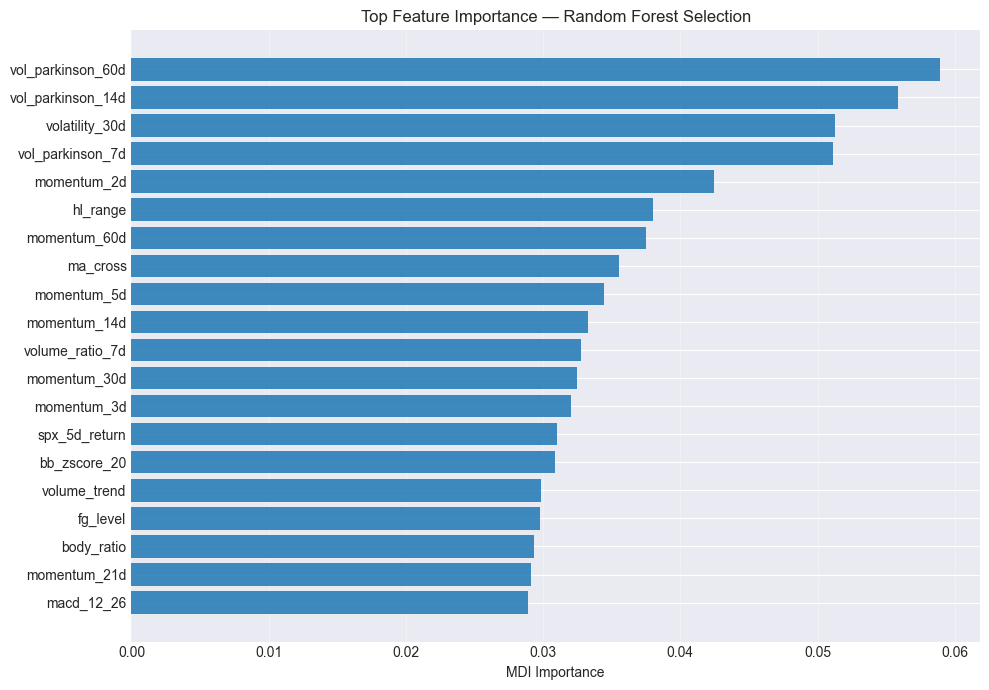

In [ ]:
top_k = 20

imp_plot = importance_df.sort_values(
    "mdi_importance",
    ascending=False
).head(top_k)

plt.figure(figsize=(10, 7))

plt.barh(
    imp_plot.index[::-1],
    imp_plot["mdi_importance"][::-1],
    alpha=0.85
)

plt.xlabel("MDI Importance")
plt.title("Top Feature Importance — Random Forest Selection")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Confusion Matrices

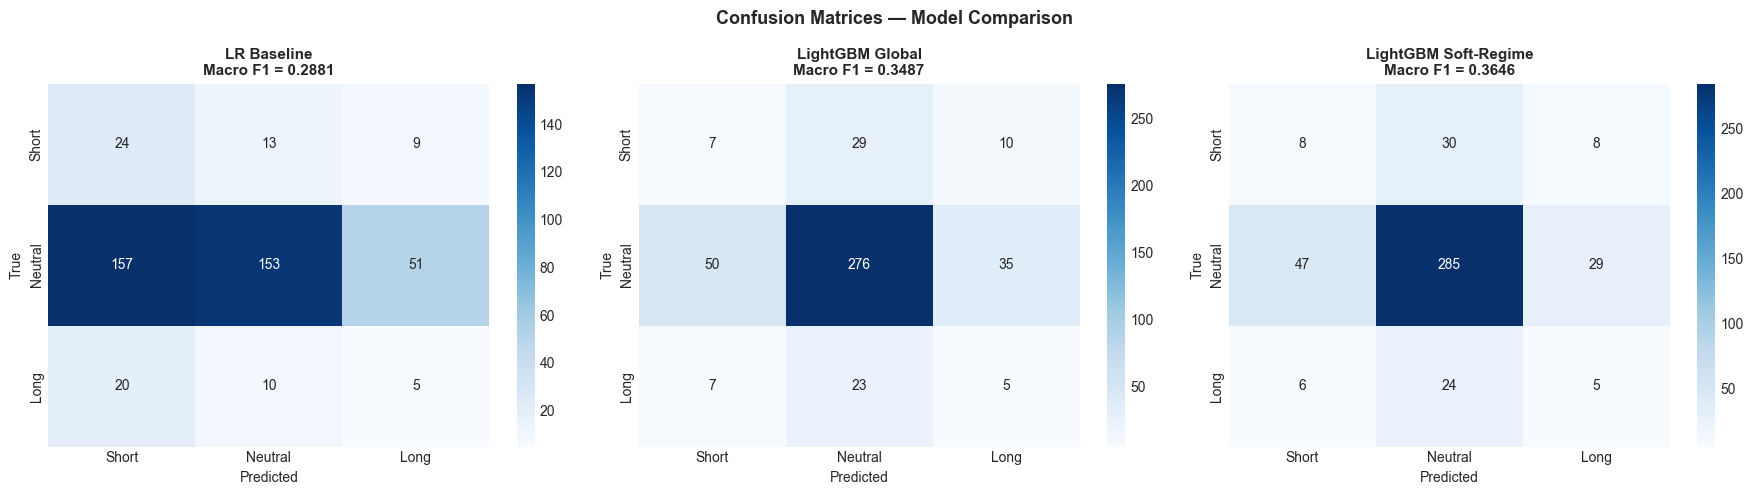

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred) in zip(axes, results.items()):
    cm  = confusion_matrix(y_test, y_pred, labels=[-1, 0, 1])
    mf1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Short', 'Neutral', 'Long'],
                yticklabels=['Short', 'Neutral', 'Long'])
    ax.set_title(f'{name}\nMacro F1 = {mf1:.4f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle('Confusion Matrices — Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. HMM Regime Visualisation — Test Period

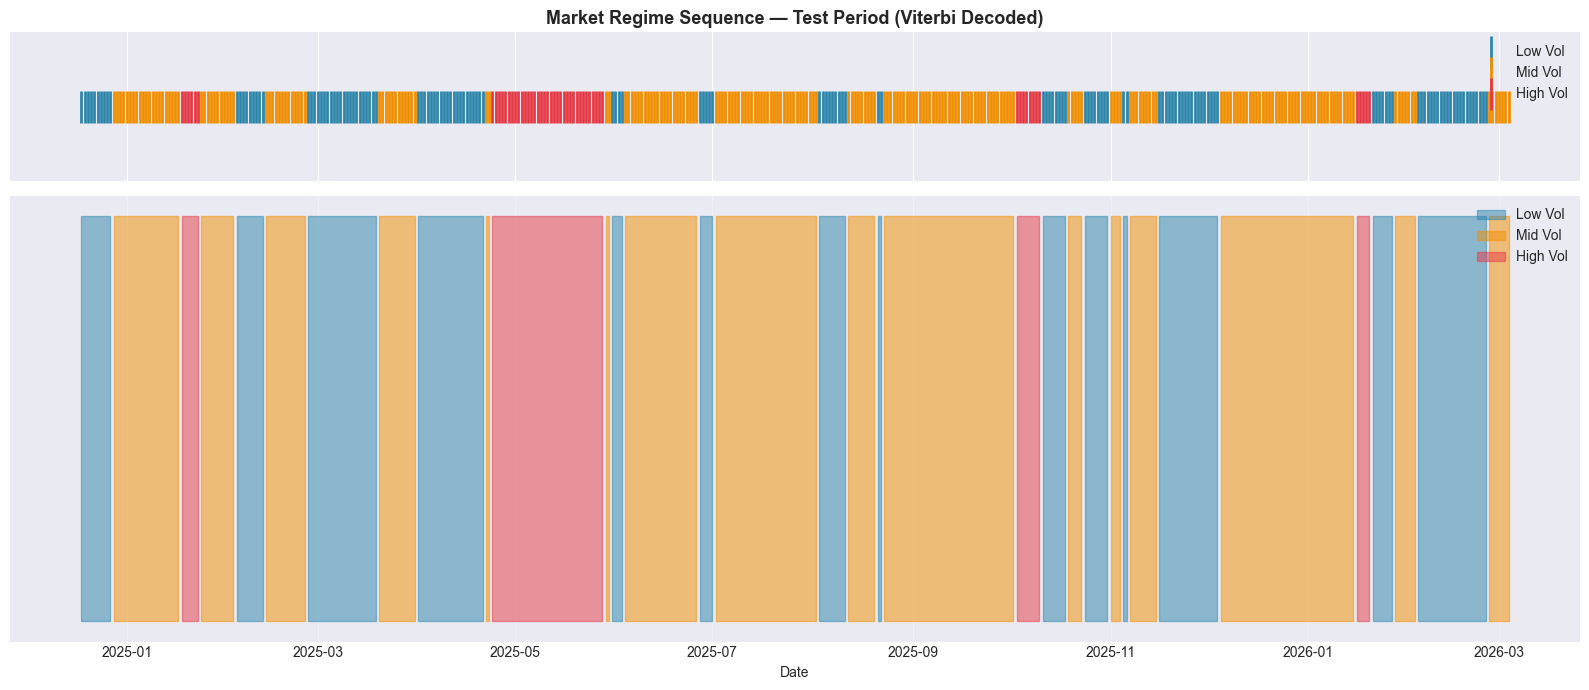

In [37]:
COLORS       = ['#2E86AB', '#F18F01', '#E63946']
REGIME_NAMES = {0: 'Low Vol', 1: 'Mid Vol', 2: 'High Vol'}
test_regimes = X_test_reg['regime'].values

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True,
                          gridspec_kw={'height_ratios': [1, 3]})

for i in range(3):
    mask = test_regimes == i
    axes[0].scatter(X_test_f.index[mask], [1]*mask.sum(),
                    color=COLORS[i], marker='|', s=500, linewidths=2,
                    label=REGIME_NAMES[i])
axes[0].set_title('Market Regime Sequence — Test Period (Viterbi Decoded)',
                   fontsize=13, fontweight='bold')
axes[0].set_yticks([])
axes[0].legend(loc='upper right')

for i in range(3):
    mask = test_regimes == i
    axes[1].fill_between(X_test_f.index, 0, 1, where=mask,
                          color=COLORS[i], alpha=0.5, label=REGIME_NAMES[i])
axes[1].set_xlabel('Date')
axes[1].set_yticks([])
axes[1].legend(loc='upper right')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Feature Importance — Soft-Regime LightGBM

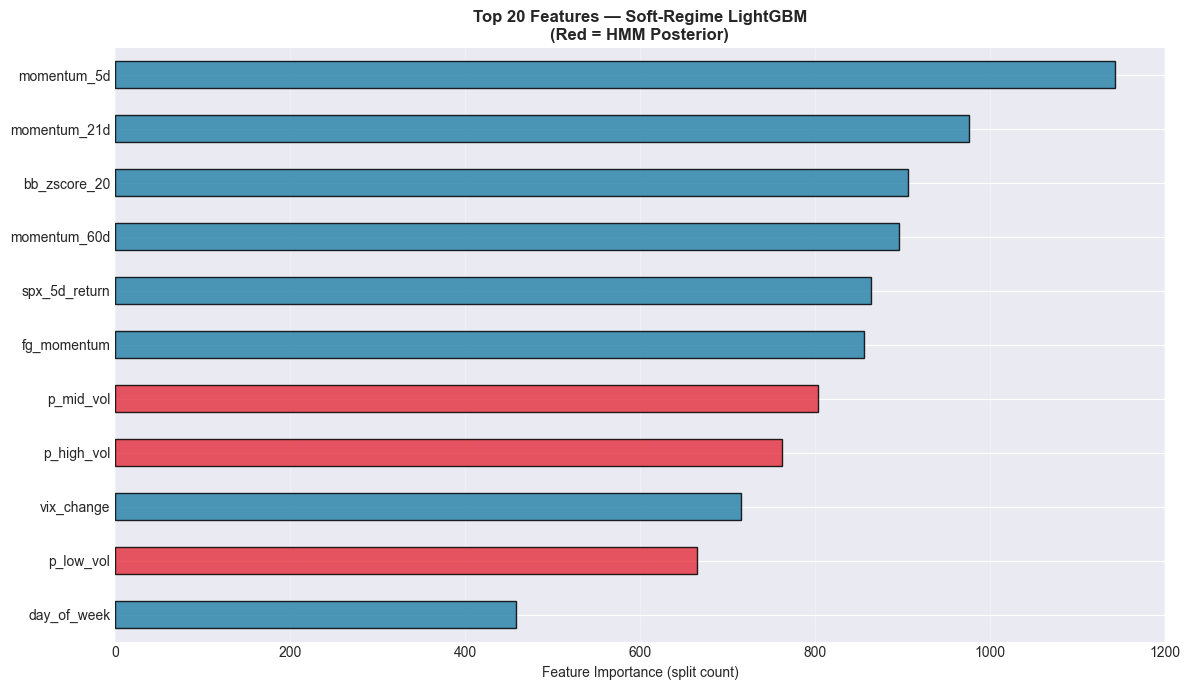


Posterior feature ranks:
  p_low_vol            rank 10/11
  p_mid_vol            rank 7/11
  p_high_vol           rank 8/11


In [38]:
lgbm_soft = models['LightGBM Soft-Regime']
imp = pd.Series(lgbm_soft.feature_importances_,
                index=X_train_soft.columns).sort_values(ascending=False)

post_cols = ['p_low_vol', 'p_mid_vol', 'p_high_vol']
colors    = ['#E63946' if f in post_cols else '#2E86AB' for f in imp.head(20).index]

fig, ax = plt.subplots(figsize=(12, 7))
imp.head(20).plot.barh(ax=ax, color=colors, edgecolor='black', alpha=0.85)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (split count)')
ax.set_title('Top 20 Features — Soft-Regime LightGBM\n'
             '(Red = HMM Posterior)', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nPosterior feature ranks:')
for col in post_cols:
    rank = list(imp.index).index(col) + 1
    print(f'  {col:<20} rank {rank}/{len(imp)}')

## 6. Walk-Forward Validation

Model is not converging.  Current: 3082.370572406652 is not greater than 9472.854013707052. Delta is -6390.4834413004


WALK-FORWARD VALIDATION
  Initial train window : 24 months
  Step size            : 3 months
  Models               : LR | Global LGBM | Soft-Regime LGBM

  Total folds : 16
  Fold   Train start    Train end     Test end  Test days
  ----- ------------ ------------ ------------ ----------
  1       2020-03-02   2022-03-02   2022-06-02         92
  2       2020-03-02   2022-06-02   2022-09-02         92
  3       2020-03-02   2022-09-02   2022-12-02         91
  4       2020-03-02   2022-12-02   2023-03-02         90
  5       2020-03-02   2023-03-02   2023-06-02         92
  6       2020-03-02   2023-06-02   2023-09-02         92
  7       2020-03-02   2023-09-02   2023-12-02         91
  8       2020-03-02   2023-12-02   2024-03-02         91
  9       2020-03-02   2024-03-02   2024-06-02         92
  10      2020-03-02   2024-06-02   2024-09-02         92
  11      2020-03-02   2024-09-02   2024-12-02         91
  12      2020-03-02   2024-12-02   2025-03-02         90
  13      2020

Model is not converging.  Current: 10971.884822343245 is not greater than 11250.79660755463. Delta is -278.911785211385



  Fold 1  [2022-03-02 → 2022-06-02]  n_test=92  thr=3.75%
    LR=0.3346  Global=0.3889  Soft=0.3499

  Fold 2  [2022-06-02 → 2022-09-02]  n_test=92  thr=3.73%
    LR=0.3836  Global=0.4888  Soft=0.4874


Model is not converging.  Current: 2089.016660818618 is not greater than 9952.988925794114. Delta is -7863.972264975496


...


  Fold 14  [2025-06-02 → 2025-09-02]  n_test=92  thr=3.00%
    LR=0.3291  Global=0.3182  Soft=0.3182


Model is not converging.  Current: 21474.792099893617 is not greater than 21478.91080593009. Delta is -4.118706036471849



  Fold 15  [2025-09-02 → 2025-12-02]  n_test=91  thr=2.96%
    LR=0.3012  Global=0.3382  Soft=0.3382


Model is not converging.  Current: 3837.7271144998317 is not greater than 26474.744052451726. Delta is -22637.016937951896



  Fold 16  [2025-12-02 → 2026-03-02]  n_test=90  thr=2.88%
    LR=0.2422  Global=0.3268  Soft=0.3548

WALK-FORWARD RESULTS — FOLD-BY-FOLD
 fold  train_end   test_end  n_test  lr_macro_f1  global_macro_f1  soft_macro_f1
    1 2022-03-02 2022-06-02      92       0.3346           0.3889         0.3499
    2 2022-06-02 2022-09-02      92       0.3836           0.4888         0.4874
    3 2022-09-02 2022-12-02      91       0.2763           0.3098         0.3077
    4 2022-12-02 2023-03-02      90       0.2744           0.3166         0.3274
    5 2023-03-02 2023-06-02      92       0.2994           0.2949         0.2972
    6 2023-06-02 2023-09-02      92       0.3121           0.3142         0.3142
    7 2023-09-02 2023-12-02      91       0.3008           0.3056         0.4185
    8 2023-12-02 2024-03-02      91       0.2702           0.3384         0.4097
    9 2024-03-02 2024-06-02      92       0.1413           0.3147         0.3261
   10 2024-06-02 2024-09-02      92       0.2718   

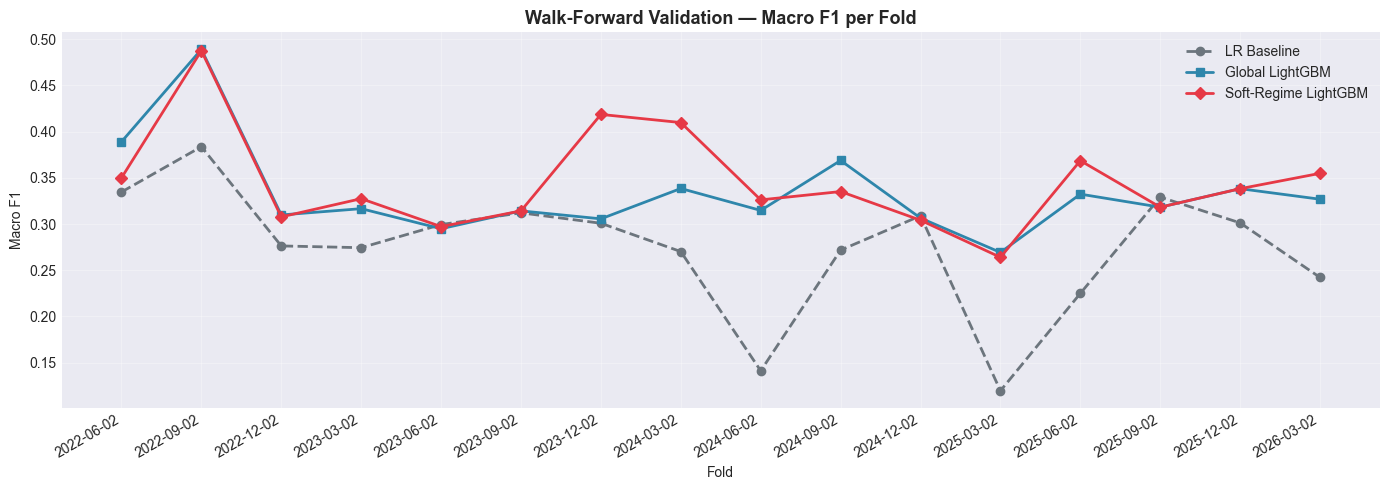

In [39]:
from walk_forward import run_walk_forward, summarise_wfv

wfv_results = run_walk_forward(df_ml, best_params)
summarise_wfv(wfv_results)

# Plot
x = wfv_results['fold']
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(x, wfv_results['lr_macro_f1'],     marker='o', color='#6c757d',
        linewidth=2, label='LR Baseline', linestyle='--')
ax.plot(x, wfv_results['global_macro_f1'], marker='s', color='#2E86AB',
        linewidth=2, label='Global LightGBM')
ax.plot(x, wfv_results['soft_macro_f1'],   marker='D', color='#E63946',
        linewidth=2, label='Soft-Regime LightGBM')
ax.set_xlabel('Fold')
ax.set_ylabel('Macro F1')
ax.set_title('Walk-Forward Validation — Macro F1 per Fold',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([str(d) for d in wfv_results['test_end']],
                   rotation=30, ha='right')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Backtest Equity Curves

In [40]:
from backtest import (
    calculate_metrics, build_binary_position,
    build_confidence_position, build_regime_aware_position,
    build_mixed_position, regime_breakdown
)

# --- Step 1: Data Preparation ---
test_idx     = y_test.index
log_ret_test = df_ml.loc[test_idx, 'future_return']
regime_test  = X_test_reg['regime'].values

lgbm_soft   = models['LightGBM Soft-Regime']
lgbm_global = models['LightGBM Global']
pred_soft    = lgbm_soft.predict(X_test_soft)
proba_soft   = lgbm_soft.predict_proba(X_test_soft)
pred_global  = lgbm_global.predict(X_test_f)
proba_global = lgbm_global.predict_proba(X_test_f)

# --- Step 2: Generating Positions ---
pos_bah = pd.Series(1.0, index=log_ret_test.index)
pos_b   = build_binary_position(pred_global).set_axis(log_ret_test.index)
pos_c   = build_confidence_position(pred_global, proba_global).set_axis(log_ret_test.index)
pos_d   = build_regime_aware_position(pred_soft, proba_soft, regime_test).set_axis(log_ret_test.index)
pos_e   = build_mixed_position(pred_soft, proba_soft, regime_test).set_axis(log_ret_test.index)

# --- Step 3: Metrics Calculation ---
COST_BPS = 0.001
res_a = calculate_metrics(pos_bah, log_ret_test, 'A) Buy & Hold',       0)
res_b = calculate_metrics(pos_b,   log_ret_test, 'B) Binary LGBM', COST_BPS)
res_c = calculate_metrics(pos_c,   log_ret_test, 'C) Confidence',  COST_BPS)
res_d = calculate_metrics(pos_d,   log_ret_test, 'D) Regime v1',   COST_BPS)
res_e = calculate_metrics(pos_e,   log_ret_test, 'E) Mixed (C×E)', COST_BPS)

all_results = [res_a, res_b, res_c, res_d, res_e]

# --- Step 4: Summary Output ---
summary_df = pd.DataFrame(
    [{k: v for k, v in r.items() if not k.startswith('_') and k != 'Equity'}
     for r in all_results]
)
print('\n' + '=' * 80)
print('FINAL BACKTEST SUMMARY')
print('=' * 80)
print(summary_df[['Strategy', 'Return %', 'Ann Ret %', 'Sharpe',
                   'Sortino', 'Max DD %', 'Trades']].to_string(index=False))

# Regime breakdown for Strategy E
regime_breakdown(res_e, log_ret_test, regime_test, 'Strategy E')


FINAL BACKTEST SUMMARY
      Strategy  Return %  Ann Ret %  Sharpe  Sortino  Max DD %  Trades
 A) Buy & Hold   -26.822    -25.787  -0.566   -0.759   -49.534       0
B) Binary LGBM    -2.167     -1.809  -0.067   -0.054   -17.222     153
 C) Confidence    25.265     18.602   1.763    1.827    -6.242      91
  D) Regime v1     4.105      3.322   0.300    0.246   -10.503      90
E) Mixed (C×E)     5.440      4.374   0.294    0.230   -15.556      88

  Regime breakdown — Strategy E
  ------------------------------------------------------------
  Regime  Trades  Win Rate %  Avg P&L/Trade  Regime Sharpe
 Low Vol      55        47.3         0.0003         -0.133
 Mid Vol      44        50.0         0.1464          0.770
High Vol       2       100.0         0.6790          2.906


,Regime,Trades,Win Rate %,Avg P&L/Trade,Regime Sharpe
0,Low Vol,55,47.3,0.0003,-0.133
1,Mid Vol,44,50.0,0.1464,0.770
2,High Vol,2,100.0,0.6790,2.906


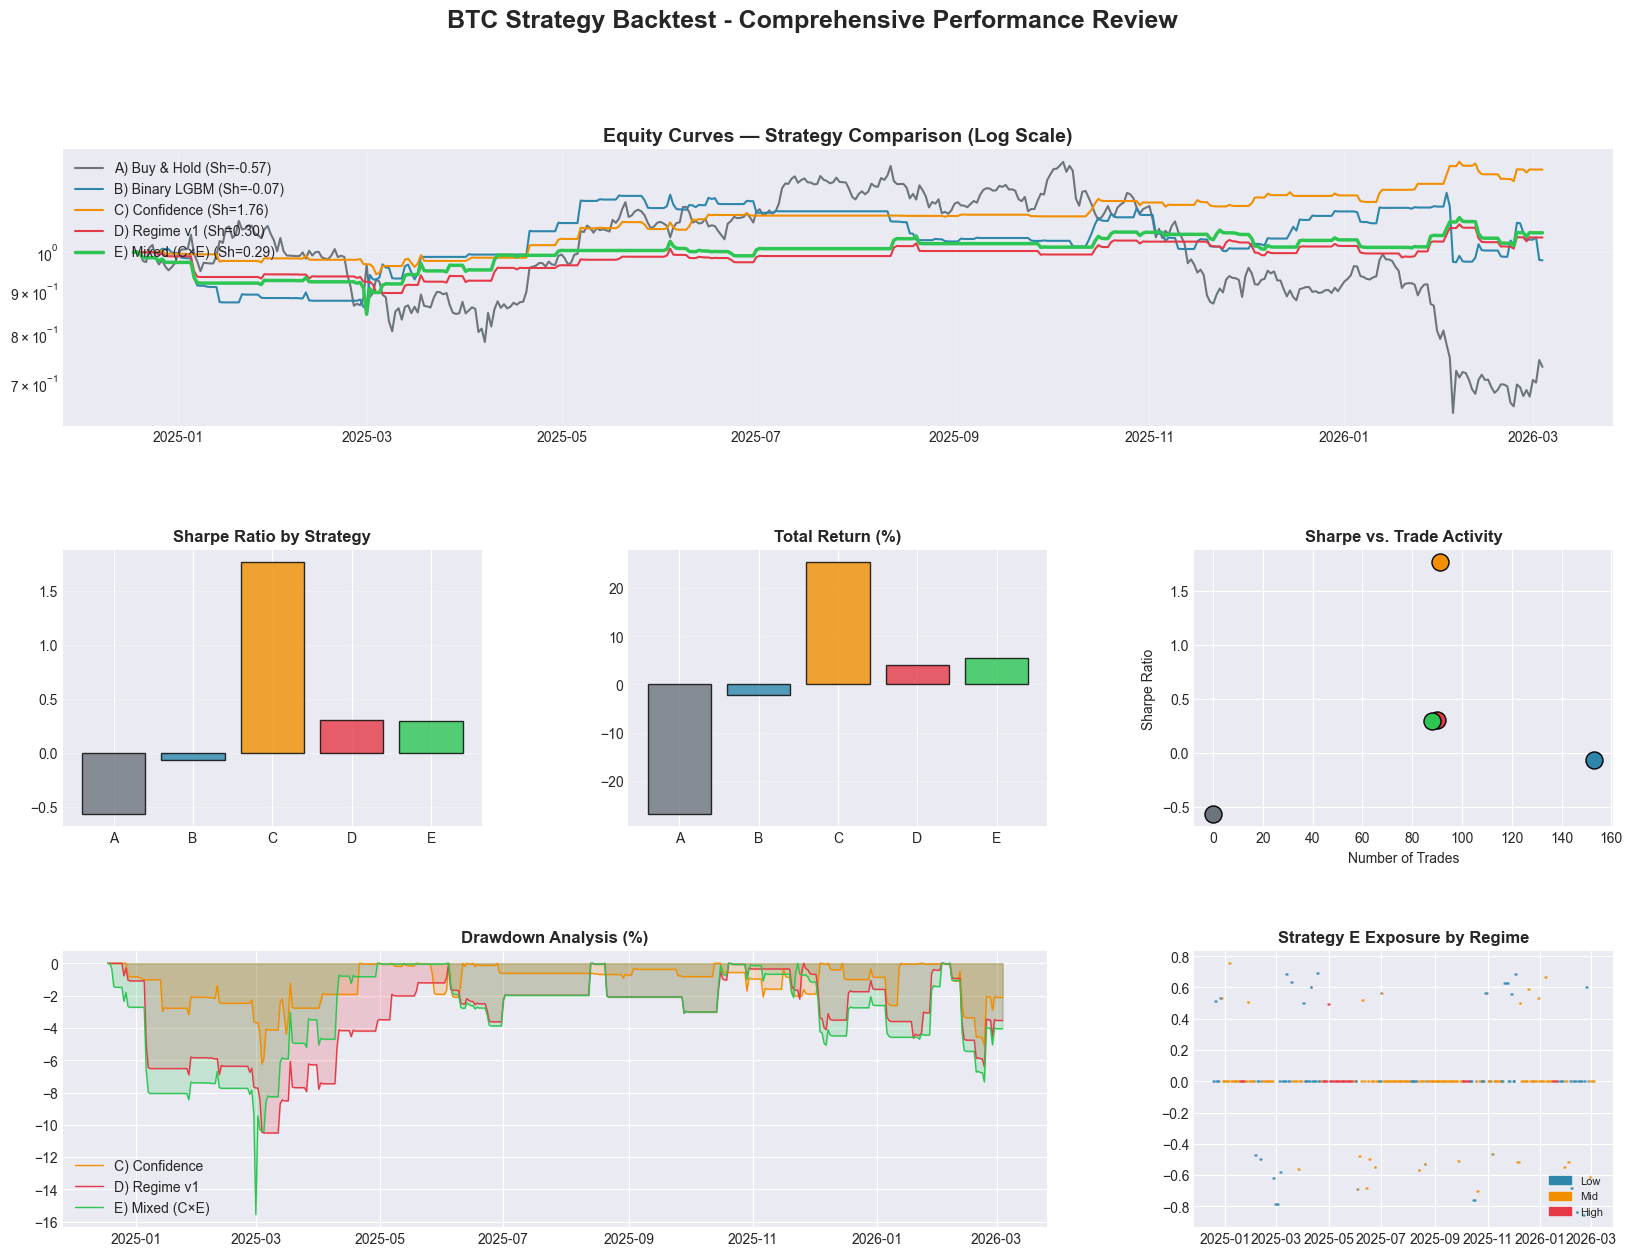


 WINNING STRATEGY: C) Confidence
 Sharpe      : 1.763
 Return %    : 25.265
 Max DD %    : -6.242
 Trades      : 91
--------------------------------------------------
 Conclusion: The strategy effectively balances risk by 
 adapting position size and entry hurdles per market regime.


In [41]:
colors = ['#6c757d', '#2E86AB', '#F18F01', '#E63946', '#2dc653']
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# Panel 1: Equity Curves (full width)
ax1 = fig.add_subplot(gs[0, :])
for res, color in zip(all_results, colors):
    lw = 2.5 if 'Mixed' in res['Strategy'] else 1.5
    ax1.plot(res['Equity'].index, res['Equity'], color=color, lw=lw,
             label=f"{res['Strategy']} (Sh={res['Sharpe']:.2f})")
ax1.set_yscale('log')
ax1.set_title('Equity Curves — Strategy Comparison (Log Scale)',
              fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)

# Panel 2: Sharpe Ratio Comparison
ax2 = fig.add_subplot(gs[1, 0])
sharpe_vals = [r['Sharpe'] for r in all_results]
ax2.bar(['A', 'B', 'C', 'D', 'E'], sharpe_vals,
        color=colors, alpha=0.8, edgecolor='black')
ax2.set_title('Sharpe Ratio by Strategy', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Panel 3: Total Return %
ax3 = fig.add_subplot(gs[1, 1])
ret_vals = [r['Return %'] for r in all_results]
ax3.bar(['A', 'B', 'C', 'D', 'E'], ret_vals,
        color=colors, alpha=0.8, edgecolor='black')
ax3.set_title('Total Return (%)', fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# Panel 4: Sharpe vs Trade Count
ax4 = fig.add_subplot(gs[1, 2])
for r, color, lbl in zip(all_results, colors, ['A', 'B', 'C', 'D', 'E']):
    ax4.scatter(r['Trades'], r['Sharpe'], color=color, s=150,
                edgecolor='black', label=lbl)
ax4.set_xlabel('Number of Trades')
ax4.set_ylabel('Sharpe Ratio')
ax4.set_title('Sharpe vs. Trade Activity', fontweight='bold')

# Panel 5: Drawdown Analysis (C, D, E)
ax5 = fig.add_subplot(gs[2, :2])
for res, color in zip([res_c, res_d, res_e], colors[2:]):
    dd = (res['Equity'] - res['Equity'].cummax()) / res['Equity'].cummax() * 100
    ax5.fill_between(dd.index, dd, 0, alpha=0.2, color=color)
    ax5.plot(dd.index, dd, color=color, lw=1, label=res['Strategy'])
ax5.set_title('Drawdown Analysis (%)', fontweight='bold')
ax5.legend()

# Panel 6: Strategy E Exposure by Regime
ax6 = fig.add_subplot(gs[2, 2])
regime_map = {0: '#2E86AB', 1: '#F18F01', 2: '#E63946'}
pos_e_exec = res_e['_exec_pos']
for r_id in [0, 1, 2]:
    mask = regime_test == r_id
    ax6.scatter(pos_e_exec.index[mask], pos_e_exec[mask],
                color=regime_map[r_id], s=1, alpha=0.5)
ax6.set_title('Strategy E Exposure by Regime', fontweight='bold')
legend_patches = [
    mpatches.Patch(color=regime_map[i], label=n)
    for i, n in {0: 'Low', 1: 'Mid', 2: 'High'}.items()
]
ax6.legend(handles=legend_patches, loc='lower right', fontsize=8)

plt.suptitle('BTC Strategy Backtest - Comprehensive Performance Review',
             fontsize=18, fontweight='bold')
plt.show()

# --- Winning Strategy ---
def print_best_strategy(results):
    active_strategies = [r for r in results if r['Trades'] > 20]
    best = max(active_strategies, key=lambda x: x['Sharpe'])
    print('\n' + '=' * 50)
    print(f" WINNING STRATEGY: {best['Strategy']}")
    print('=' * 50)
    for metric in ['Sharpe', 'Return %', 'Max DD %', 'Trades']:
        print(f" {metric:<12}: {best[metric]}")
    print('-' * 50)
    print(' Conclusion: The strategy effectively balances risk by ')
    print(' adapting position size and entry hurdles per market regime.')

print_best_strategy(all_results)